# Displacement Orders Data EDA notebook

> In this notebook, we will explore displacement orders to:
>  * uncover patterns.
> * identify trends. 
> * gain insights into their impact on the people of Gaza.

## Import Modules

In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime

In [2]:
sns.set_theme(style="whitegrid")

In [65]:
gazamap_data = pd.read_csv(
    "1_datasets/data/clean_datasets/gaza_displacement_cleaned.csv"
)

### General Trends & Overview

In [66]:
gazamap_data["date"] = pd.to_datetime(gazamap_data["date"])

In [67]:
gazamap_data.sort_values(by="date", inplace=True)

In [68]:
gazamap_data["displacement_year"] = gazamap_data["date"].dt.year
gazamap_data["displacement_month"] = gazamap_data["date"].dt.month
gazamap_data["displacement_day"] = gazamap_data["date"].dt.day
gazamap_data["displacement_week_day_num"] = gazamap_data["date"].dt.weekday
day_names_map = {
    0: "Monday",
    1: "Tuesday",
    2: "Wednesday",
    3: "Thursday",
    4: "Friday",
    5: "Saturday",
    6: "Sunday",
}
gazamap_data["displacement_week_day"] = gazamap_data["displacement_week_day_num"].map(
    day_names_map
)

### Get all dates betwen start and end date even there are no displacement orders in certian days

In [75]:
full_date_range = pd.date_range(gazamap_data["date"].min(), gazamap_data["date"].max())
full_dates = pd.DataFrame({"date": full_date_range})

In [76]:
final_gazamap = full_dates.merge(gazamap_data, on="date", how="left")
final_gazamap["id"] = final_gazamap["id"].fillna(0).astype(int)
final_gazamap["order_issued"] = final_gazamap["id"].apply(lambda x: 0 if x == 0 else 1)

### 1. How many displacement orders were issued over time?

In [60]:
dates_groups = (
    final_gazamap.groupby(["date"]).agg({"order_issued": "sum"}).reset_index()
)
dates_groups.rename({"order_issued": "num_orders"}, axis=1, inplace=True)

In [43]:
dates = [
    str(datetime.date(year=x.year, month=x.month, day=x.day))
    for x in pd.date_range(
        gazamap_data["date"].min(), gazamap_data["date"].max(), freq="MS"
    ).to_list()
]

In [77]:
# Step 1: Grouping
daily_stats = (
    final_gazamap.groupby("date")
    .agg(
        order_count=("order_issued", "sum"),
        total_displacement_area=("area_sq_km_displacement", "sum"),
        avg_displacement_area=("area_sq_km_displacement", "mean"),
    )
    .reset_index()
)


# Step 3: Merge
final_gazamap = final_gazamap.merge(daily_stats, on="date", how="left")

# Step 4: Fill missing values
final_gazamap["order_count"] = final_gazamap["order_count"].fillna(0).astype(int)
final_gazamap["total_displacement_area"] = final_gazamap[
    "total_displacement_area"
].fillna(0)
final_gazamap["avg_displacement_area"] = final_gazamap["avg_displacement_area"].fillna(
    0
)

In [78]:
final_gazamap[["date", "order_count", "id"]]

,date,order_count,id
0,2023-10-07,1,16
1,2023-10-08,0,0
2,2023-10-09,0,0
3,2023-10-10,0,0
4,2023-10-11,0,0
...,...,...,...
630,2025-06-16,0,0
631,2025-06-17,1,118
632,2025-06-18,0,0
633,2025-06-19,0,0


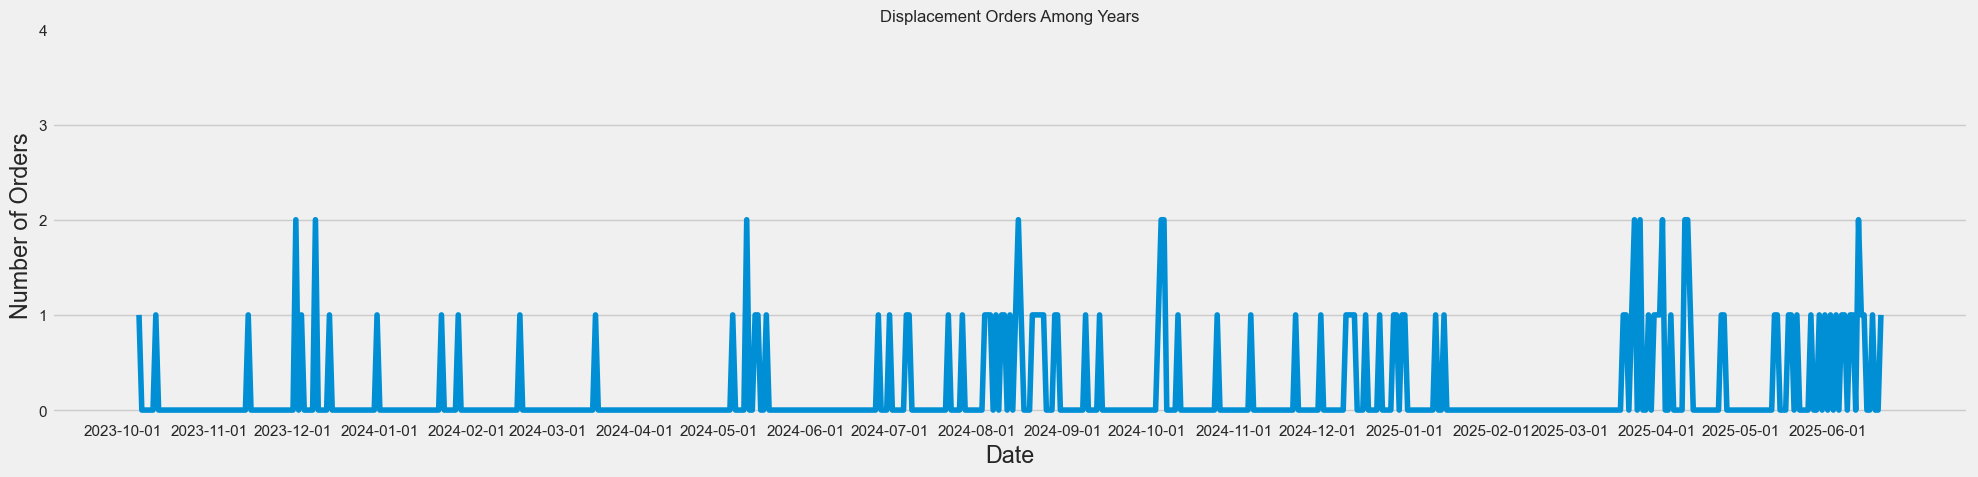

In [80]:
y_max = final_gazamap.order_count.max()
with plt.style.context("fivethirtyeight"):
    fig, ax = plt.subplots(figsize=(20, 5))
    # for row in dates_groups.iterrows():
    #     if row[1][4] >= 2:
    #         plt.axvspan(
    #             row[1][3], row[1][3] + pd.DateOffset(weeks=1), color="yellow", alpha=0.2
    #         )

    sns.lineplot(data=final_gazamap, x="date", y="order_count", ax=ax)
    plt.title("Displacement Orders Among Years", fontsize=12)
    plt.xlabel("Date")
    plt.ylabel("Number of Orders")
    plt.yticks(range(0, int(y_max) + 3))
    plt.xticks(
        pd.date_range(
            final_gazamap["date"].min() - pd.DateOffset(weeks=1),
            final_gazamap["date"].max(),
            freq="MS",
        )
    )
    plt.grid(axis="x")
    plt.tight_layout()
    plt.show()

As we can see there are some intensive months with number of displacement orders like:
* 12/2023
* 05/2024 - 02/2025 
* end of 03/2025 - mid 05/2025 
* 06/2025
There are some less intensive months like: 02/2025, 03/2025 because there were temporarl cease-fire

### Affected area time trend

C:\Users\MSI\AppData\Local\Temp\ipykernel_2336\2495672716.py:6: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if row[1][9] >= 50:  # putting a threshold with 50 km distance of evacuation
C:\Users\MSI\AppData\Local\Temp\ipykernel_2336\2495672716.py:8: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  row[1][1], row[1][1] + pd.DateOffset(days=3), color="yellow", alpha=0.3
C:\Users\MSI\AppData\Local\Temp\ipykernel_2336\2495672716.py:10: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access

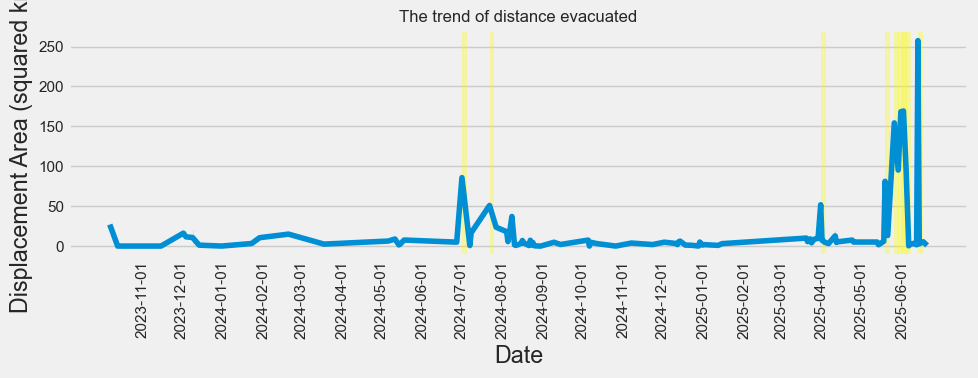

In [84]:
y_max = final_gazamap.area_sq_km_displacement.max()
most_displacement_areas = []
with plt.style.context("fivethirtyeight"):
    fig, ax = plt.subplots(nrows=1, figsize=(10, 4))
    for row in final_gazamap.iterrows():
        if row[1][9] >= 50:  # putting a threshold with 50 km distance of evacuation
            plt.axvspan(
                row[1][1], row[1][1] + pd.DateOffset(days=3), color="yellow", alpha=0.3
            )
            most_displacement_areas.append(row[1][1])

    sns.lineplot(data=final_gazamap, x="date", y="area_sq_km_displacement", ax=ax)
    plt.title("The trend of distance evacuated", fontsize=12)
    plt.xlabel("Date")
    plt.ylabel("Displacement Area (squared km)")
    # plt.yticks(range(0, int(y_max) + 3))
    plt.xticks(dates, rotation="vertical")
    plt.grid(axis="x")
    plt.tight_layout()
    plt.show()

Zoom in the most evacuated area dates

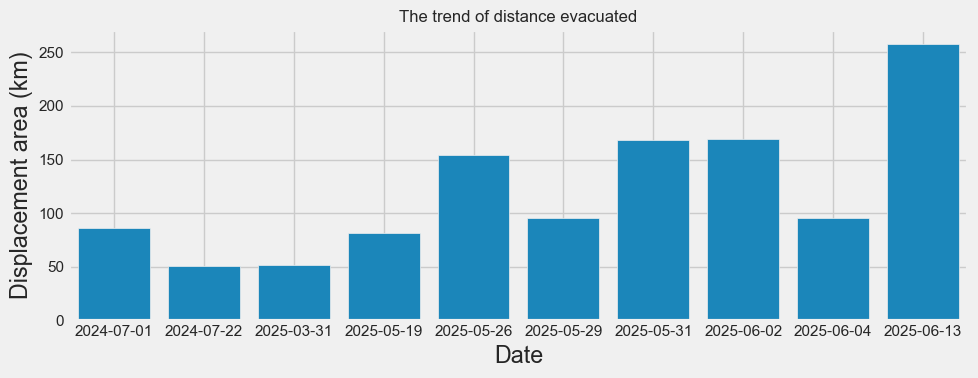

In [85]:
most_displaced_df = final_gazamap[final_gazamap["date"].isin(most_displacement_areas)]
with plt.style.context("fivethirtyeight"):
    fig, ax = plt.subplots(nrows=1, figsize=(10, 4))
    sns.barplot(data=most_displaced_df, x="date", y="area_sq_km_displacement", ax=ax)
    plt.title("The trend of distance evacuated", fontsize=12)
    plt.xlabel("Date")
    plt.ylabel("Displacement area (km)")
    plt.grid(axis="x")
    plt.tight_layout()
    plt.show()

You can see there are overlaps between dates and months, regarding 2023 most of displacement happend to the north so not much of area were evacuated in comparison to 2024 and 2025 when orders have caused evacuation to more and more areas in north and south as well

### Is there a trend on the week day of displacement order?

In [88]:
final_gazamap["is_work_day"] = np.where(
    final_gazamap["displacement_week_day"].isin(
        ["Saturday", "Sunday", "Monday", "Tuesday", "Wednesday", "Thursday"]
    ),
    "Yes",
    "No",
)

In [90]:
week_day_groups = (
    final_gazamap.groupby("displacement_week_day")
    .agg({"order_count": "sum"})
    .reset_index()
    .rename(columns={"order_count": "num_orders"})
)

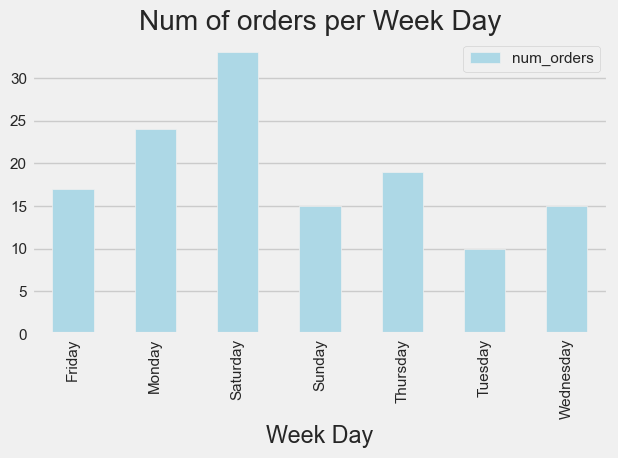

In [92]:
with plt.style.context("fivethirtyeight"):
    colors = ["lightblue"]
    week_day_groups.plot(
        kind="bar", x="displacement_week_day", y="num_orders", color=colors
    )
    plt.xlabel("Week Day")
    plt.title("Num of orders per Week Day")
    plt.grid(axis="x")
    plt.tight_layout()
    plt.show()

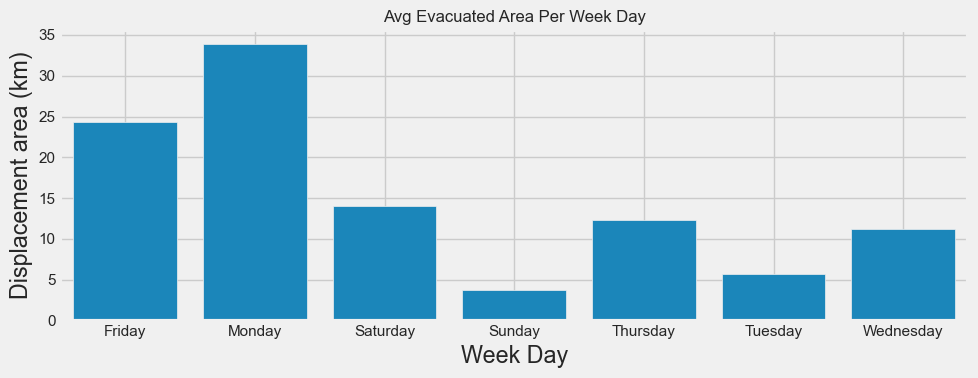

In [93]:
week_days_displacement = final_gazamap.groupby(
    "displacement_week_day", as_index=False
).agg(avg_evacuated_area=("area_sq_km_displacement", "mean"))
with plt.style.context("fivethirtyeight"):
    fig, ax = plt.subplots(nrows=1, figsize=(10, 4))
    sns.barplot(
        data=week_days_displacement,
        x="displacement_week_day",
        y="avg_evacuated_area",
        ax=ax,
    )
    plt.title("Avg Evacuated Area Per Week Day", fontsize=12)
    plt.xlabel("Week Day")
    plt.ylabel("Displacement area (km)")
    plt.grid(axis="x")
    plt.tight_layout()
    plt.show()

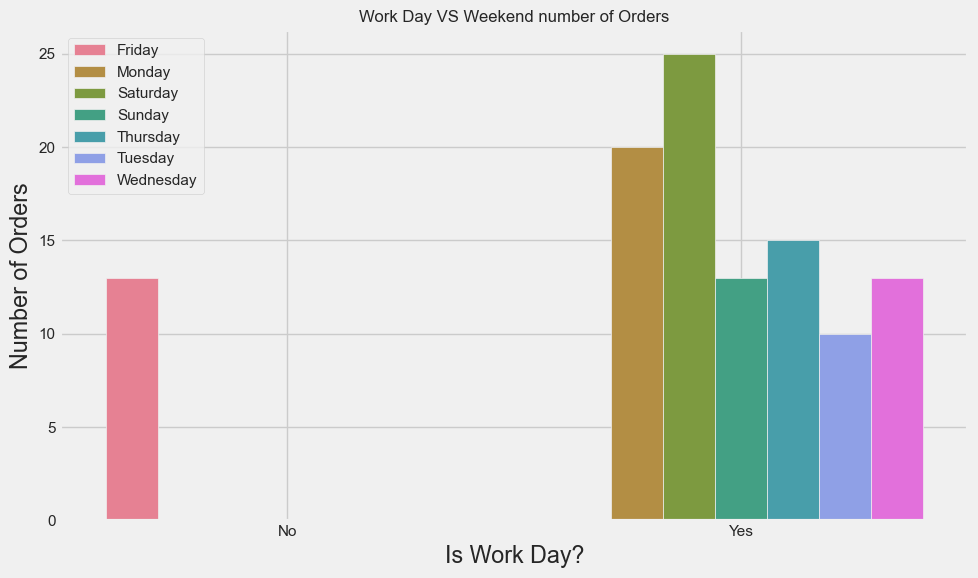

In [94]:
day_type_groups = (
    final_gazamap.groupby(["is_work_day", "displacement_week_day"])
    .agg({"id": "count"})
    .reset_index()
    .rename(columns={"id": "num_orders"})
)
with plt.style.context("fivethirtyeight"):
    fig, ax = plt.subplots(nrows=1, figsize=(10, 6))
    sns.barplot(
        data=day_type_groups,
        x="is_work_day",
        y="num_orders",
        hue="displacement_week_day",
        ax=ax,
    )
    plt.title("Work Day VS Weekend number of Orders", fontsize=12)
    plt.xlabel("Is Work Day?")
    plt.ylabel("Number of Orders")
    plt.grid(axis="x")
    plt.tight_layout()
    plt.legend(loc="upper left")
    plt.show()

### Key finding: As the most of orders were issued on the work days (according to arabic calendar) so that affects students performance for sure, because majority of exams, activites, sessions will be issued from Saturday-Thursday (Friday is the weekend) espacially on IUG

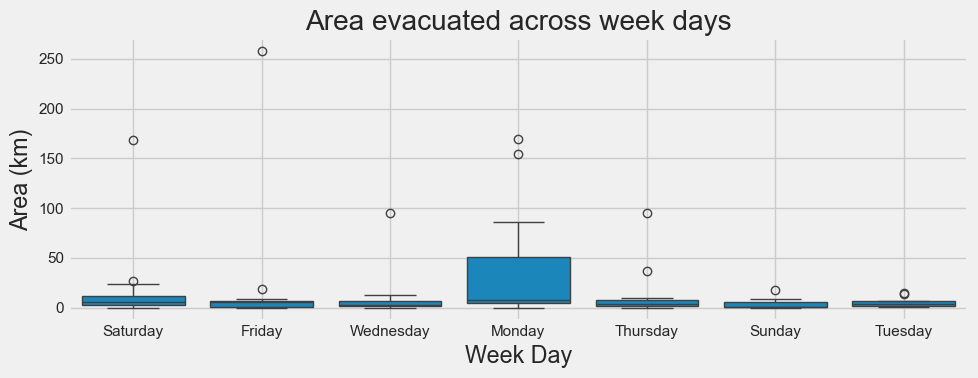

In [95]:
with plt.style.context("fivethirtyeight"):
    fig, axes = plt.subplots(nrows=1, figsize=(10, 4))
    sns.boxplot(
        data=final_gazamap,
        x="displacement_week_day",
        y="area_sq_km_displacement",
        ax=axes,
    )
    plt.xlabel("Week Day")
    plt.ylabel("Area (km)")
    plt.title("Area evacuated across week days")
    plt.grid(axis="x")
    plt.tight_layout()
    plt.show()

In [118]:
new_record = {
    "id": 9999,  # integer, unique identifier
    "date": pd.to_datetime("2023-10-01"),  # string or datetime, e.g. 'YYYY-MM-DD'
    "source": "NA",  # string, source of the data
    "link": "https://example.org/report",  # string, URL to source
    "map_idf": "map_101",  # string, map identifier
    "map_full": True,  # boolean, whether the map is full
    "map_zoom": 10,  # integer or float, zoom level
    "displacement_blocks": 0,  # integer, number of displaced blocks
    "labeled_safe_blocks": 0,  # integer, number of safe blocks labeled
    "area_sq_km_displacement": 0,  # float, area of displacement in sq km
    "area_sq_km_labeled_safe": 0,  # float, area labeled as safe
    "displacement_year": 2023,  # integer, year part of the date
    "displacement_month": 7,  # integer, month part of the date
    "displacement_day": 1,  # integer, day part of the date
}
final_gazamap = pd.concat(
    [final_gazamap, pd.DataFrame([new_record])], ignore_index=True
)

In [119]:
final_gazamap[final_gazamap["displacement_year"] == 2023]

,date,id,source,link,map_idf,map_full,map_zoom,displacement_blocks,labeled_safe_blocks,area_sq_km_displacement,...,displacement_year,displacement_month,displacement_day,displacement_week_day_num,displacement_week_day,order_issued,order_count,total_displacement_area,avg_displacement_area,is_work_day
0,2023-10-07 00:00:00,16,https://x.com/avichayadraee/status/17107769972...,https://gazamaps.com/displacement/16,https://gazamaps.com/storage/displacement-maps...,https://gazamaps.com/storage/displacement-maps...,https://gazamaps.com/storage/displacement-maps...,"10, 11, 12, 569, 570, 571, 574, 578, 579, 580,...",NaN,27.00,...,2023.0,10.0,7.0,5.0,Saturday,1.0,1.0,27.00,27.000,Yes
6,2023-10-13 00:00:00,102,https://x.com/AvichayAdraee/status/17128464937...,https://gazamaps.com/displacement/102,https://gazamaps.com/storage/displacement-maps...,NaN,NaN,NaN,NaN,0.00,...,2023.0,10.0,13.0,4.0,Friday,1.0,1.0,0.00,0.000,No
39,2023-11-15 00:00:00,105,https://x.com/AvichayAdraee/status/17246987877...,https://gazamaps.com/displacement/105,https://gazamaps.com/storage/displacement-maps...,NaN,NaN,NaN,NaN,0.00,...,2023.0,11.0,15.0,2.0,Wednesday,1.0,1.0,0.00,0.000,Yes
56,2023-12-02 00:00:00,42,https://x.com/AvichayAdraee/status/17308498684...,https://gazamaps.com/displacement/42,https://gazamaps.com/storage/displacement-maps...,https://gazamaps.com/storage/displacement-maps...,https://gazamaps.com/storage/displacement-maps...,"699, 713, 714, 715, 718, 719, 723, 754, 755, 7...",NaN,11.74,...,2023.0,12.0,2.0,5.0,Saturday,1.0,2.0,32.37,16.185,Yes
57,2023-12-02 00:00:00,18,https://x.com/AvichayAdraee/status/17308498684...,https://gazamaps.com/displacement/18,https://gazamaps.com/storage/displacement-maps...,https://gazamaps.com/storage/displacement-maps...,https://gazamaps.com/storage/displacement-maps...,"578, 602, 604, 605, 606, 607, 608, 609, 617, 6...",NaN,20.63,...,2023.0,12.0,2.0,5.0,Saturday,1.0,2.0,32.37,16.185,Yes
59,2023-12-04 00:00:00,41,https://x.com/AvichayAdraee/status/17315393673...,https://gazamaps.com/displacement/41,https://gazamaps.com/storage/displacement-maps...,https://gazamaps.com/storage/displacement-maps...,https://gazamaps.com/storage/displacement-maps...,"36, 38, 39, 40, 41, 42.1, 42.2, 42.3, 43, 44, ...",NaN,11.57,...,2023.0,12.0,4.0,0.0,Monday,1.0,1.0,11.57,11.570,Yes
64,2023-12-09 00:00:00,40,https://x.com/AvichayAdraee/status/17330363333...,https://gazamaps.com/displacement/40,https://gazamaps.com/storage/displacement-maps...,https://gazamaps.com/storage/displacement-maps...,https://gazamaps.com/storage/displacement-maps...,"578, 602, 604, 605, 606, 607, 608, 609, 617, 6...",NaN,20.63,...,2023.0,12.0,9.0,5.0,Saturday,1.0,2.0,21.37,10.685,Yes
65,2023-12-09 00:00:00,32,https://x.com/AvichayAdraee/status/17334859338...,https://gazamaps.com/displacement/32,https://gazamaps.com/storage/displacement-maps...,https://gazamaps.com/storage/displacement-maps...,https://gazamaps.com/storage/displacement-maps...,"47, 55, 103, 104, 105, 106",NaN,0.74,...,2023.0,12.0,9.0,5.0,Saturday,1.0,2.0,21.37,10.685,Yes
70,2023-12-14 00:00:00,31,https://x.com/AvichayAdraee/status/17352163458...,https://gazamaps.com/displacement/31,https://gazamaps.com/storage/displacement-maps...,https://gazamaps.com/storage/displacement-maps...,https://gazamaps.com/storage/displacement-maps...,"47, 56, 59, 67, 101, 102, 103, 104, 105, 106",NaN,1.15,...,2023.0,12.0,14.0,3.0,Thursday,1.0,1.0,1.15,1.150,Yes
87,2023-12-31 00:00:00,11,https://x.com/avichayadraee/status/17403070877...,https://gazamaps.com/displacement/11,https://gazamaps.com/storage/displacement-maps...,NaN,NaN,NaN,NaN,0.00,...,2023.0,12.0,31.0,6.0,Sunday,1.0,1.0,0.00,0.000,Yes


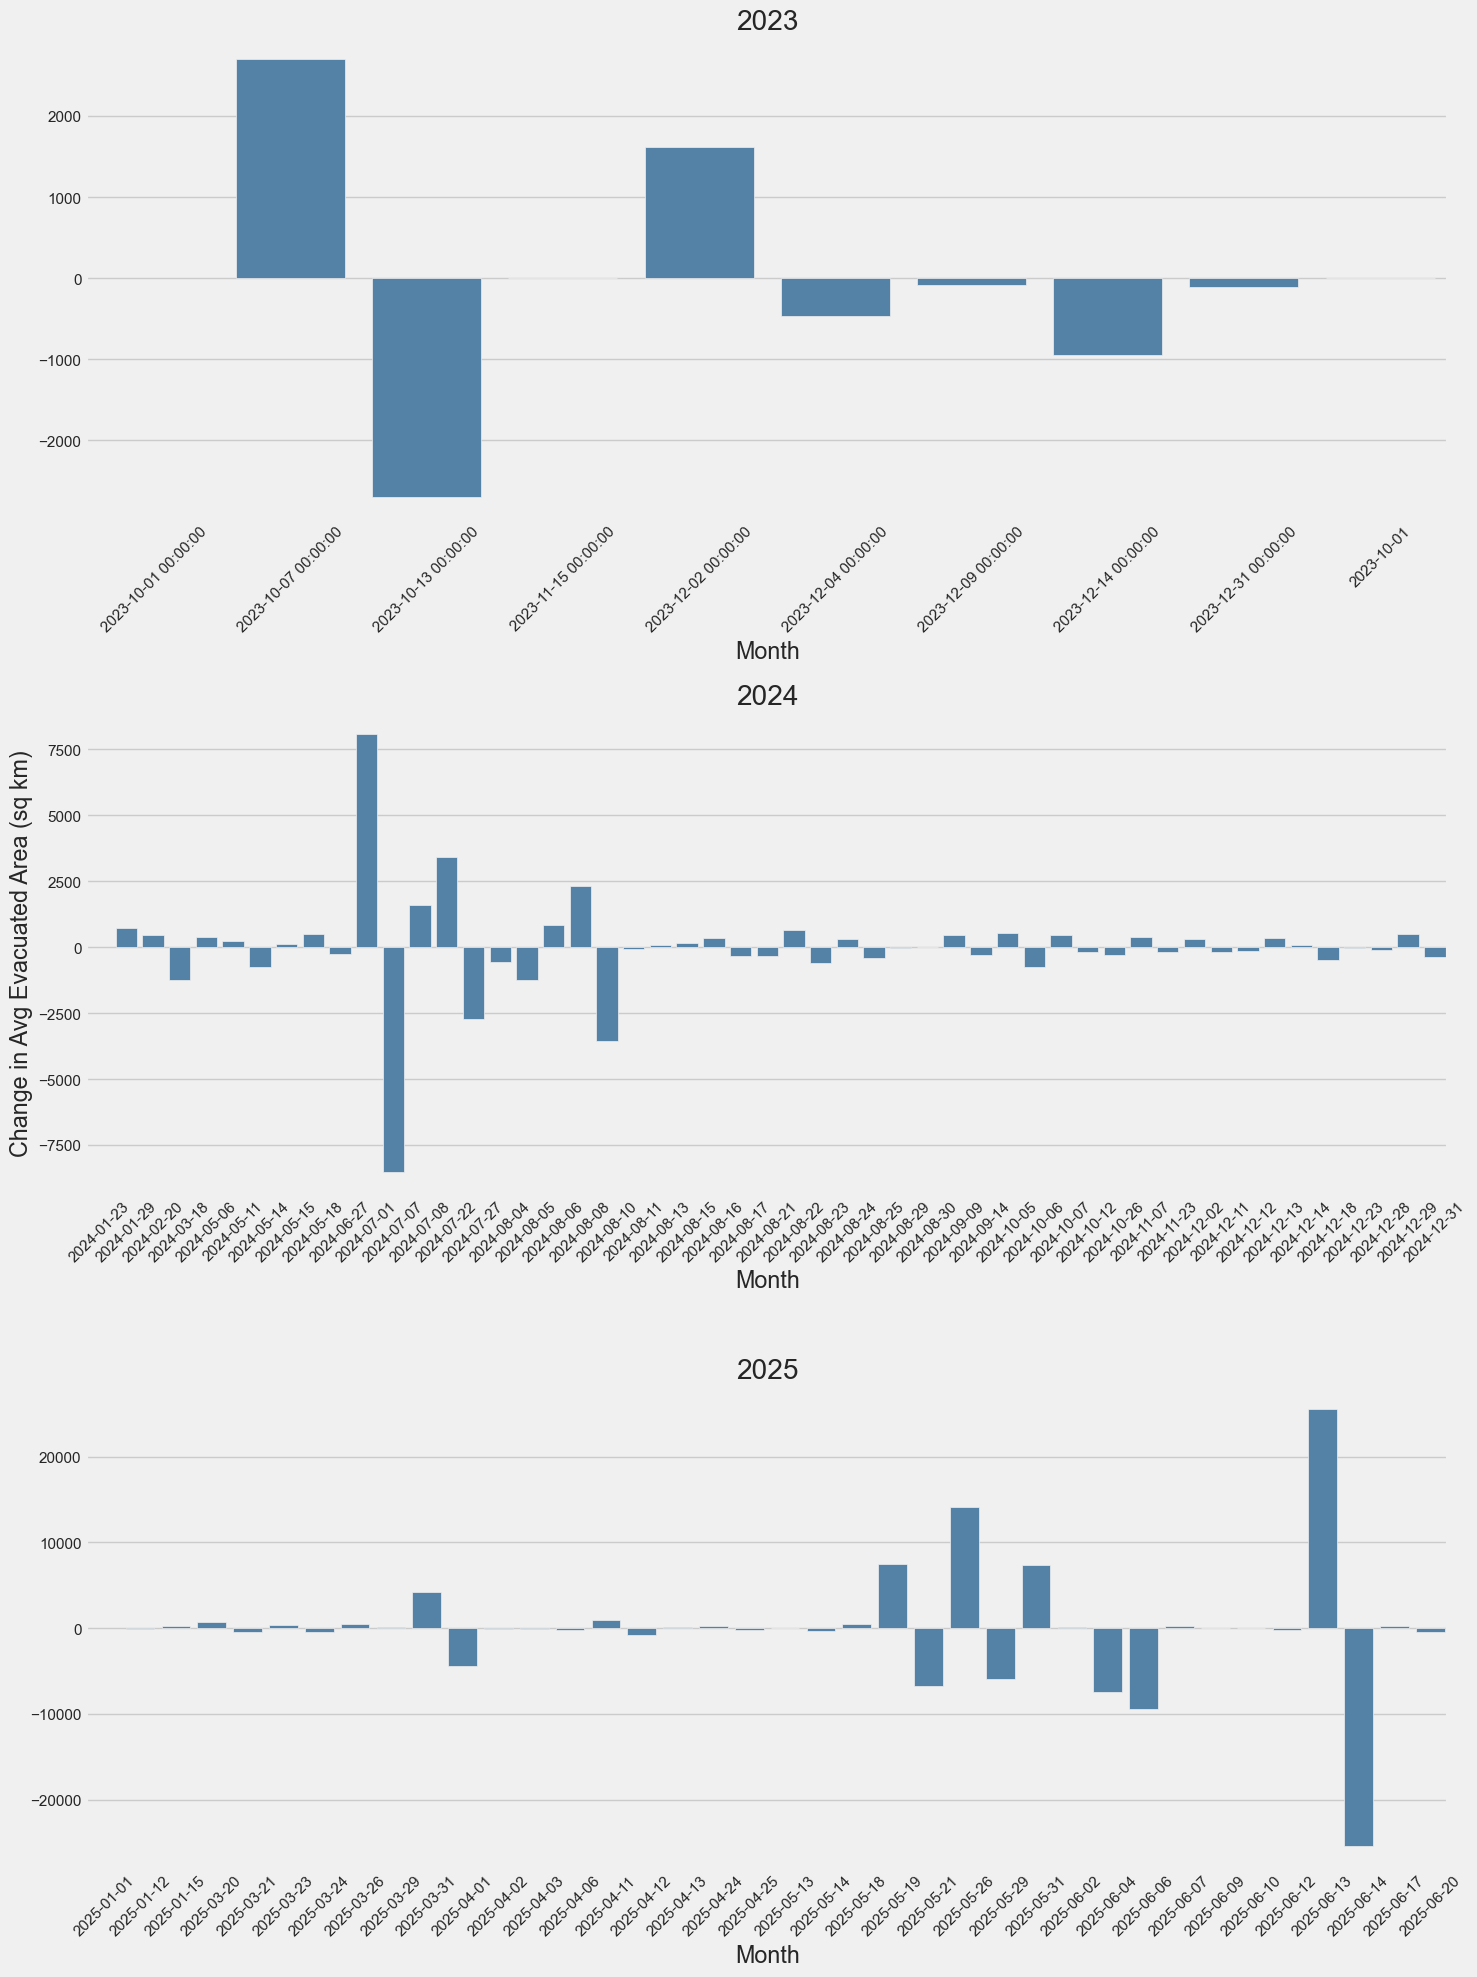

In [120]:
with plt.style.context("fivethirtyeight"):
    fig, axes = plt.subplots(nrows=3, figsize=(15, 20))
    years = [2023, 2024, 2025]
    for i, year in enumerate(years):
        monthly_order_num_change = (
            final_gazamap[final_gazamap["displacement_year"] == year]
            .groupby(["date"])["area_sq_km_displacement"]
            .mean()
        )
        monthly_order_num_change = monthly_order_num_change.diff().reset_index()
        monthly_order_num_change.rename(
            columns={"area_sq_km_displacement": "Rate Change in Evacuated Area"},
            inplace=True,
        )
        monthly_order_num_change["Rate Change in Evacuated Area"] *= 100
        sns.barplot(
            data=monthly_order_num_change,
            x="date",
            y="Rate Change in Evacuated Area",
            ax=axes[i],
            color="steelblue",
        )

        axes[i].set_title(f"{year}")
        axes[i].set_xlabel("Month")
        axes[i].tick_params(axis="x", rotation=45)
        axes[i].set_ylabel("")
    axes[1].set_ylabel("Change in Avg Evacuated Area (sq km)")
    plt.tight_layout()
    plt.show()